In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

In [32]:
dfVentas = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSYz9Te7ugIr7tKtBxlwny-B7Hf18VS1F-wS-UzyIkRB7V5LfEBQbicgK-1WMSvzYMbckP6RCZXTZSU/pub?output=csv')
dfClientes = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTHb6ptnC3cgqdYl6plOhXKkM2QjtF28a60Xs3MhWvYBWItL4DjRIIaxFxmVeXqDUQmpIxgAD3rtUqE/pub?output=csv')
dfMarketing = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSVDYEjlSHtOjTpj6aysH9H38Nm5Ob-4kaFahqfMzLqQO9lgkHLg1PH9TjObzeH--sPXgNpxubLUtab/pub?output=csv')

dfVentas

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos
...,...,...,...,...,...,...
3030,1837,Horno eléctrico,$104.12,9.0,30/12/2024,Electrodomésticos
3031,2276,Laptop,$85.27,9.0,30/12/2024,Electrónica
3032,2696,Laptop,$107.81,4.0,30/12/2024,Electrónica
3033,2913,Smartphone,$99.85,7.0,30/12/2024,Electrónica


In [33]:
# Script para calcular las ventas mensuales

# parámetros :
# -format : para indicar el formato de la fecha y,
# -errors : para evitar valores nulos (lo transforma en NaT)
dfVentas['fecha_venta'] = pd.to_datetime(dfVentas['fecha_venta'], format='%d/%m/%Y', errors='coerce')
dfVentas['fecha_venta']

dfVentas['mes'] = dfVentas['fecha_venta'].dt.month

dfVentas['precio'] = dfVentas['precio'].str.replace('$', '')
dfVentas['precio'] = pd.to_numeric(dfVentas['precio'], errors='coerce')
dfVentas['precio_final'] = dfVentas['precio'] * dfVentas['cantidad']

ventas_mensuales = dfVentas.groupby('mes')['precio_final'].sum()

ventas_mensuales

,precio_final
mes,
1,129604.99
2,118672.44
3,136779.15
4,144380.10
5,143727.25
6,108480.17
7,116229.97
8,119680.15
9,115787.85


###Modificaciones necesarias para el script:
- Se cambia el tipo de datos de la columna 'fecha_venta' a datatime para poder trabajar sobre las fechas.
- Agrego columna 'mes' para poder agrupar por ese criterio.
- Modificación del tipo de dato en columna 'precio' para trabajar los valores.
###Uso de la función groupby para el obtener el calculo de ventas mensuales.

In [34]:
# Desarrollar un programa que almacene los datos de ventas (producto, precio, cantidad).
# Decidir si conviene utilizar diccionarios o listas.

datosDeVentas = dfVentas[['producto', 'precio', 'cantidad']]


# orient='records' permite tomar cada linea como un diccionario
# el nombre de la columna es la clave
dictVentas = datosDeVentas.to_dict(orient='records')

dictVentas[0]['producto']

'Cuadro decorativo'

### Me oriente por un diccionario para facilitar la identificación de los registros, tanto como su acceso.
### Pasos realizados para la generación del programa:
- reducir el dataframe a las tres columnas necesarias
- convertir el nuevo df a un diccionario

In [35]:
# La función -info()- brinda un panorama general del dataframe.
# Es posible identificar nombres de columnas, tipo de dato almacenado y cantidad de registros.
# Así como la cantidad de registros nulos en cada columna.

dfVentas.info()
print()
print()
dfClientes.info()
print()
print()
dfMarketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_venta      3035 non-null   int64         
 1   producto      3035 non-null   object        
 2   precio        3033 non-null   float64       
 3   cantidad      3033 non-null   float64       
 4   fecha_venta   3035 non-null   datetime64[ns]
 5   categoria     3035 non-null   object        
 6   mes           3035 non-null   int32         
 7   precio_final  3033 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int32(1), int64(1), object(2)
memory usage: 178.0+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_cliente  567 non-null    int64  
 1   nombre      567 non-null    object 
 2   edad        567 non-null  

  -->  La función head()

In [36]:
# La función head() nos permite visualizar los datos en forma general.
# Es posible obtener una cantidad 'n' de registros.

print("dataframe VENTAS")
print(dfVentas.head())
print()
print()
print("dataframe CLIENTES")
print(dfClientes.head(10))
print()
print()
print("dataframe MARKETING")
print(dfMarketing.head(3))

dataframe VENTAS
   id_venta           producto  precio  cantidad fecha_venta  \
0       792  Cuadro decorativo   69.94       5.0  2024-01-02   
1       811    Lámpara de mesa  105.10       5.0  2024-01-02   
2      1156           Secadora   97.96       3.0  2024-01-02   
3      1372           Heladera  114.35       8.0  2024-01-02   
4      1546           Secadora  106.21       4.0  2024-01-02   

           categoria  mes  precio_final  
0         Decoración    1        349.70  
1         Decoración    1        525.50  
2  Electrodomésticos    1        293.88  
3  Electrodomésticos    1        914.80  
4  Electrodomésticos    1        424.84  


dataframe CLIENTES
   id_cliente               nombre  edad                 ciudad  ingresos
0           1      Aloysia Screase    44          Mar del Plata  42294.68
1           2  Kristina Scaplehorn    25                Posadas  24735.04
2           3       Filip Castagne    50            Resistencia  35744.85
3           4          Liuka 

  --> La función -isnull()-

In [37]:
# Da mayor claridad en cuánto a la cantidad de valores nulos en cada columna

print("df VENTAS")
print(dfVentas.isnull().sum())
print()
print("df CLIENTES")
print(dfClientes.isnull().sum())
print()
print("df MARKETING")
print(dfMarketing.isnull().sum())

df VENTAS
id_venta        0
producto        0
precio          2
cantidad        2
fecha_venta     0
categoria       0
mes             0
precio_final    2
dtype: int64

df CLIENTES
id_cliente    0
nombre        0
edad          0
ciudad        0
ingresos      0
dtype: int64

df MARKETING
id_campanha     0
producto        0
canal           0
costo           0
fecha_inicio    0
fecha_fin       0
dtype: int64


  -->  La función -describe()-

In [38]:
# Permite obtener valores estadísticos de los dataframes.
# Tanto de todo el df como de algunas columnas

print(dfVentas['precio'].describe())
print()
print(dfClientes['ingresos'].describe())
print()
dfMarketing.describe(include='all')

count    3033.000000
mean       75.289034
std        28.734666
min        26.000000
25%        50.020000
50%        75.270000
75%       100.040000
max       124.970000
Name: precio, dtype: float64

count      567.000000
mean     34668.739012
std      12974.531446
min        170.290000
25%      26015.240000
50%      35066.830000
75%      42457.100000
max      88053.010000
Name: ingresos, dtype: float64



,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
count,90.000000,90,90,90.000000,90,90
unique,NaN,30,3,NaN,78,78
top,NaN,Adorno de pared,TV,NaN,25/09/2024,05/05/2024
freq,NaN,3,30,NaN,2,3
mean,45.500000,NaN,NaN,4.928667,NaN,NaN
std,26.124701,NaN,NaN,0.947750,NaN,NaN
min,1.000000,NaN,NaN,2.950000,NaN,NaN
25%,23.250000,NaN,NaN,4.372500,NaN,NaN
50%,45.500000,NaN,NaN,4.900000,NaN,NaN
75%,67.750000,NaN,NaN,5.562500,NaN,NaN


  -->  La función -duplicate()-

In [39]:
# Brinda un panoramo de registros duplicados en los dataframes
print("Cantidad de duplicados en VENTAS : ",dfVentas.duplicated().sum(), " de ", len(dfVentas))
print("Cantidad de duplicados en CLIENTES : ",dfClientes.duplicated().sum(), " de ", len(dfClientes))
print("Cantidad de duplicados en MARKETING : ",dfMarketing.duplicated().sum(), " de ", len(dfMarketing))

Cantidad de duplicados en VENTAS :  35  de  3035
Cantidad de duplicados en CLIENTES :  0  de  567
Cantidad de duplicados en MARKETING :  0  de  90


### Resultado del análisis exploratorio :
  - La cantidad de valores nulos es insignificante, sería viable su eliminación.
  - Ocurre lo mismo con los valores duplicados.

#----------------------------------------------------------------------------------

In [40]:
# Limpieza de datos, eliminación de duplicasdos y caracteres no deseados.

print("     valores nulos     ")
print("antes:")
print(dfVentas.isnull().sum())
print()
dfVentas.dropna(inplace=True)
print("después:")
print(dfVentas.isnull().sum())


print()
print()
print("Duplicados en el dataframe Ventas antes del drop_duplicate: ", dfVentas.duplicated().sum())
dfVentas.drop_duplicates(inplace=True)
print("Duplicados en el dataframe Ventas después del drop_duplicate: ", dfVentas.duplicated().sum())
print()
print()

# Se modifica el tipo de datos en las columnas 'cantidad, producto y categoría'.
dfVentas['cantidad'] = dfVentas['cantidad'].astype(int)
dfVentas['producto'] = dfVentas['producto'].astype(str)
dfVentas['categoria'] = dfVentas['categoria'].astype(str)

     valores nulos     
antes:
id_venta        0
producto        0
precio          2
cantidad        2
fecha_venta     0
categoria       0
mes             0
precio_final    2
dtype: int64

después:
id_venta        0
producto        0
precio          0
cantidad        0
fecha_venta     0
categoria       0
mes             0
precio_final    0
dtype: int64


Duplicados en el dataframe Ventas antes del drop_duplicate:  35
Duplicados en el dataframe Ventas después del drop_duplicate:  0




### DF_Ventas
- Se eliminan valores nulos ya que se detecta una cantidad irrelevante.
- Se eliminan valores duplicados

In [41]:
dfMarketing.columns
dfMarketing['fecha_inicio'] = pd.to_datetime(dfMarketing['fecha_inicio'], format='%d/%m/%Y', errors='coerce')
print("tipo de dato 'fecha_inicio' : ", dfMarketing['fecha_inicio'].apply(type).unique())

dfMarketing['fecha_fin'] = pd.to_datetime(dfMarketing['fecha_fin'], format='%d/%m/%Y', errors='coerce')
print("tipo de dato 'fecha_fin' : ", dfMarketing['fecha_fin'].apply(type).unique())

tipo de dato 'fecha_inicio' :  [<class 'pandas._libs.tslibs.timestamps.Timestamp'>]
tipo de dato 'fecha_fin' :  [<class 'pandas._libs.tslibs.timestamps.Timestamp'>]


### DF_Marketing
- se modifican tipos de datos de columnas 'fecha_inicio, fecha_fin' para un mejor procesamiento.


In [42]:
# Transormación de datos: aplicar filtros y transformaciones para crear
# una tabla de ventas que muestre solo los productos de alto rendimiento.

# inplace=True, modifica el df original.
dfProductosVendidos = dfVentas.groupby('producto')['precio_final'].sum()
dfProductosVendidos.sort_values(ascending=False, inplace=True)
dfProductosVendidos.head(10)

,precio_final
producto,
Lámpara de mesa,82276.38
Auriculares,74175.58
Microondas,72562.89
Cafetera,59607.31
Cuadro decorativo,54297.60
Smartphone,54132.44
Secadora,52115.45
Jarrón decorativo,51130.88
Batidora,50979.20


Se genera ''dfProductosVendidos que agrupa por 'producto' y acumula el 'precio_final' de cada venta.

In [43]:
 # Resumir las ventas por categoría de producto y analizar los ingresos generados
 ventasPorCategoria = dfVentas.groupby('categoria')['precio_final'].sum()

 ventasPorCategoria.sort_values(ascending=False, inplace=True)
 ventasPorCategoria

,precio_final
categoria,
Electrodomésticos,505299.63
Electrónica,482577.80
Decoración,479216.09


 El nuevo df 'ventasPorCategoria' contiene las ventas acumuladas por cada categoría.

In [44]:
# Combinar los sets de datos ventas y marketing para obtener
# una visión más amplia de las tendencias

mergeVentasMarketing = pd.merge(dfVentas, dfMarketing, on='producto', how='outer')
mergeVentasMarketing.rename(columns={'costo': 'inversión en marketing'}, inplace=True)
mergeVentasMarketing

,id_venta,producto,precio,cantidad,fecha_venta,categoria,mes,precio_final,id_campanha,canal,inversión en marketing,fecha_inicio,fecha_fin
0,630,Adorno de pared,71.99,9,2024-01-04,Decoración,1,647.91,74,TV,4.81,2024-03-20,2024-05-03
1,630,Adorno de pared,71.99,9,2024-01-04,Decoración,1,647.91,44,Email,5.08,2024-04-13,2024-05-10
2,630,Adorno de pared,71.99,9,2024-01-04,Decoración,1,647.91,14,RRSS,4.16,2024-10-22,2024-12-21
3,560,Adorno de pared,57.62,6,2024-01-07,Decoración,1,345.72,74,TV,4.81,2024-03-20,2024-05-03
4,560,Adorno de pared,57.62,6,2024-01-07,Decoración,1,345.72,44,Email,5.08,2024-04-13,2024-05-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8989,2342,Televisor,50.79,2,2024-12-16,Electrónica,12,101.58,59,Email,4.19,2024-11-20,2025-01-19
8990,2342,Televisor,50.79,2,2024-12-16,Electrónica,12,101.58,89,TV,4.98,2024-12-13,2025-02-08
8991,2422,Televisor,58.00,10,2024-12-25,Electrónica,12,580.00,29,RRSS,3.96,2024-05-17,2024-06-28
8992,2422,Televisor,58.00,10,2024-12-25,Electrónica,12,580.00,59,Email,4.19,2024-11-20,2025-01-19


#-----------------------------------------------------------------------------------

In [45]:
# Calcular medidas de tendencia central y dispersión sobre ventas.

# Medidas de tendencia central :
media = dfVentas['precio_final'].mean().round(2)
mediana = dfVentas['precio_final'].median()
moda = dfVentas['precio_final'].mode()

# -----------------------------------------

# Medidas de dispersión:
rango = np.max(dfVentas['precio_final']) - np.min(dfVentas['precio_final'])
#print(np.max(dfVentas['precio_final']))
#print(np.min(dfVentas['precio_final']))
varianza = dfVentas['precio_final'].var()
desviacion_estandar = dfVentas['precio_final'].std()



print('-------------  INFORME ESTADÍSITICO -------------')
print('Medidas de tendencia central: ')
print('             Media: ', media)
print('             Mediana: ', round(mediana, 2))
print('             Moda: ', moda[0], ' - ', moda[1])
print('             Rango: ', round(rango, 2))
print('Medidas de dispersión: ')
print('             Varianza: ', round(varianza, 2))
print('             Desviación Estándar: ', round(desviacion_estandar, 2))

-------------  INFORME ESTADÍSITICO -------------
Medidas de tendencia central: 
             Media:  489.36
             Mediana:  418.06
             Moda:  345.33  -  1058.31
             Rango:  1461.82
Medidas de dispersión: 
             Varianza:  111744.33
             Desviación Estándar:  334.28


###Conclusión:
Según el Informe Estadístico sobre el DataFrame Ventas se determina que los valores están dispersos. Tanto la varianza como la desviación estándar son valores altos.
La desviación estándar es casi el 70% de la media: 334,28/489,36 = 0,68.
Entre la media y la mediana hay 70 puntos de diferencia, doble valor en la moda y bastantes lejanos entre ellos. Además de un rango alto, lo que da cuenta que el mínimo y el máximo están bastante distantes.
Los valores estadísticos dan cuenta a simple vista de una dispersión en los datos poblacionales.

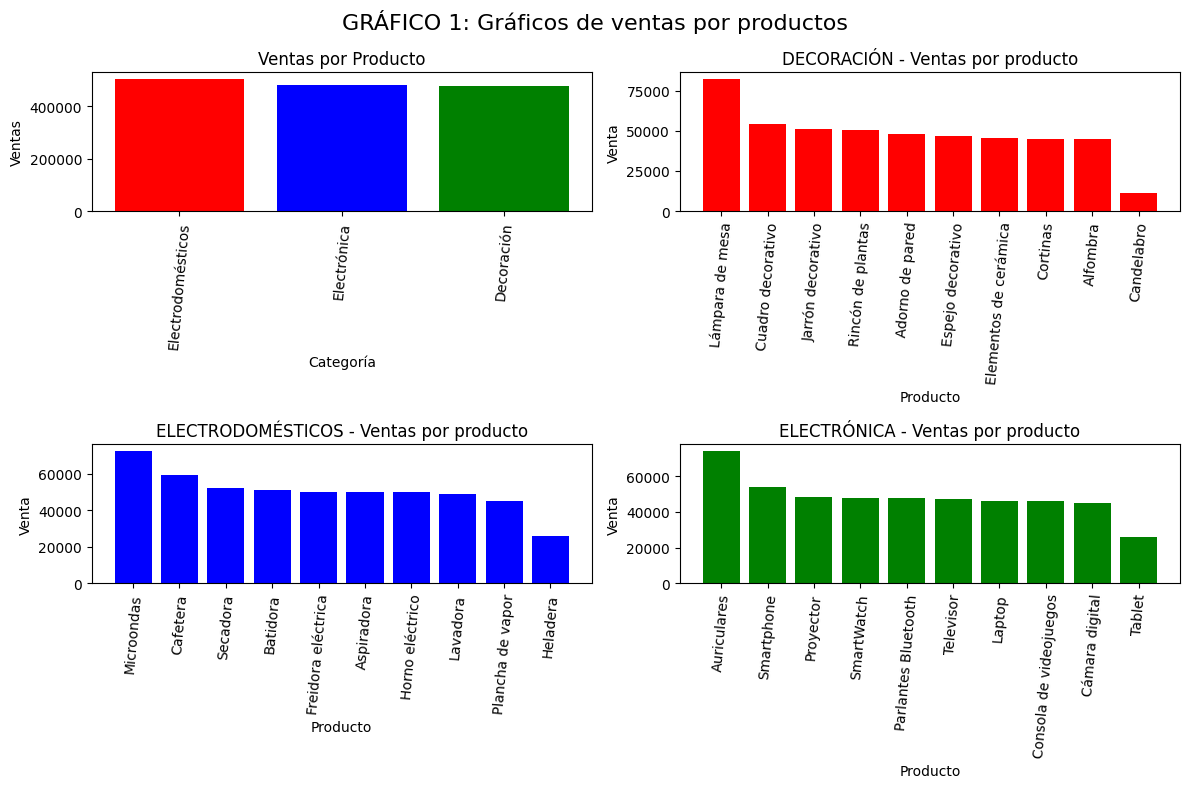

In [46]:
from pandas.core import groupby
plt.figure(figsize=(12, 8))
plt.suptitle('GRÁFICO 1: Gráficos de ventas por productos', fontsize=16)

# Agrupa las ventas por catogía
ventasPorCategoria = dfVentas.groupby('categoria')['precio_final'].sum().sort_values(ascending=False)

# Obtiene categorías y sus valores
categoria = ventasPorCategoria.index
ventas = ventasPorCategoria.values

# Gráfico por categorías
plt.subplot(2, 2, 1)
plt.bar(categoria, ventas, color=['red', 'blue', 'green'])
plt.xlabel('Categoría')
plt.ylabel('Ventas')
plt.title('Ventas por Producto')
plt.xticks(rotation=85)

# Filtros por tipos de categoría
decoracion = dfVentas[dfVentas['categoria'] == 'Decoración']
electrodomesticos = dfVentas[dfVentas['categoria'] == 'Electrodomésticos']
electronica = dfVentas[dfVentas['categoria'] == 'Electrónica']

ventas_dec = decoracion.groupby('producto')['precio_final'].sum().sort_values(ascending=False)
ventas_electro = electrodomesticos.groupby('producto')['precio_final'].sum().sort_values(ascending=False)
ventas_electronica = electronica.groupby('producto')['precio_final'].sum().sort_values(ascending=False)

# Gráfico de venta de productos en la categoría decoración
plt.subplot(2, 2, 2)
plt.bar(ventas_dec.index, ventas_dec.values, color='red')
plt.xlabel('Producto')
plt.ylabel('Venta')
plt.title('DECORACIÓN - Ventas por producto')
plt.xticks(rotation=85)

plt.subplot(2, 2, 3)
plt.bar(ventas_electro.index, ventas_electro.values, color='blue')
plt.xlabel('Producto')
plt.ylabel('Venta')
plt.title('ELECTRODOMÉSTICOS - Ventas por producto')
plt.xticks(rotation=85)


plt.subplot(2, 2, 4)
plt.bar(ventas_electronica.index, ventas_electronica.values, color='green')
plt.xlabel('Producto')
plt.ylabel('Venta')
plt.title('ELECTRÓNICA - Ventas por producto')
plt.xticks(rotation=85)

plt.tight_layout()
plt.show()


In [47]:
df_ventas_dec = pd.DataFrame(decoracion.groupby('producto')['precio_final'].sum().sort_values(ascending=False))
df_ventas_electro = pd.DataFrame(electrodomesticos.groupby('producto')['precio_final'].sum().sort_values(ascending=False))
df_ventas_electronica = pd.DataFrame(electronica.groupby('producto')['precio_final'].sum().sort_values(ascending=False))

resumen = pd.concat([
ventasPorCategoria.describe().round(2).rename('Valores estadísticos por CATEGORÍA'),
df_ventas_dec['precio_final'].describe().round(2).rename('Valores estadísiticos en  categoría DECORACIÓN'),
df_ventas_electro['precio_final'].describe().round(2).rename('Valores estadísiticos en  categoría ELECTRODOMÉSTICOS'),
df_ventas_electronica['precio_final'].describe().round(2).rename('Valores estadísiticos en  categoría ELECTRÓNICA')],
axis=1
)

resumen

,Valores estadísticos por CATEGORÍA,Valores estadísiticos en categoría DECORACIÓN,Valores estadísiticos en categoría ELECTRODOMÉSTICOS,Valores estadísiticos en categoría ELECTRÓNICA
count,3.00,10.00,10.00,10.00
mean,489031.17,47921.61,50529.96,48257.78
std,14188.81,17056.19,11628.19,11680.26
min,479216.09,11128.80,25736.80,25856.57
25%,480896.94,45001.54,49188.30,46175.68
50%,482577.80,47438.40,50120.50,47408.75
75%,493938.72,50962.27,51831.39,48099.46
max,505299.63,82276.38,72562.89,74175.58


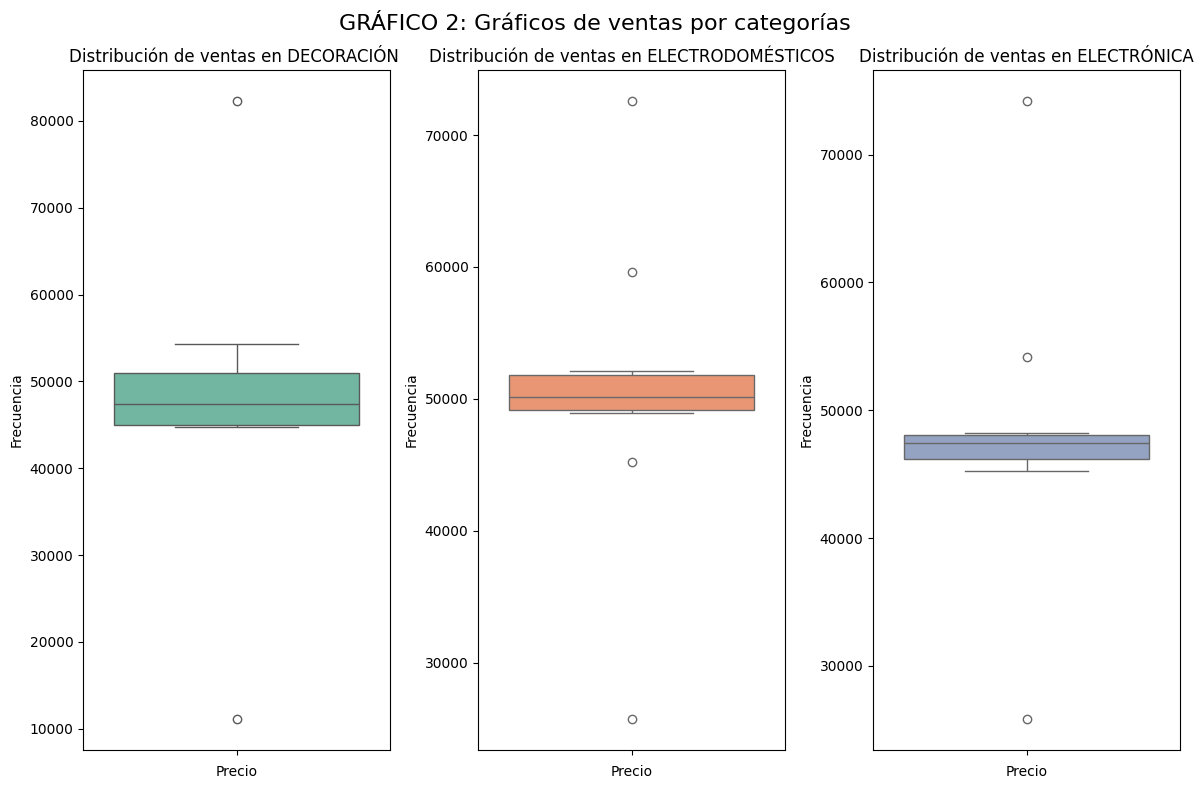

In [48]:
plt.figure(figsize=(12, 8))
plt.suptitle('GRÁFICO 2: Gráficos de ventas por categorías', fontsize=16)

# Agrupa las ventas por catogía
ventasPorCategoria = dfVentas.groupby('categoria')['precio_final'].sum().sort_values(ascending=False)

plt.subplot(1, 3, 1)
sns.boxplot(ventas_dec,
            color="#66c2a5")
plt.title('Distribución de ventas en DECORACIÓN ')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 2)
sns.boxplot(ventas_electro,
            color="#fc8d62")
plt.title('Distribución de ventas en ELECTRODOMÉSTICOS')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

plt.subplot(1, 3, 3)
sns.boxplot(ventas_electronica,
            color="#8da0cb")
plt.title('Distribución de ventas en ELECTRÓNICA')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

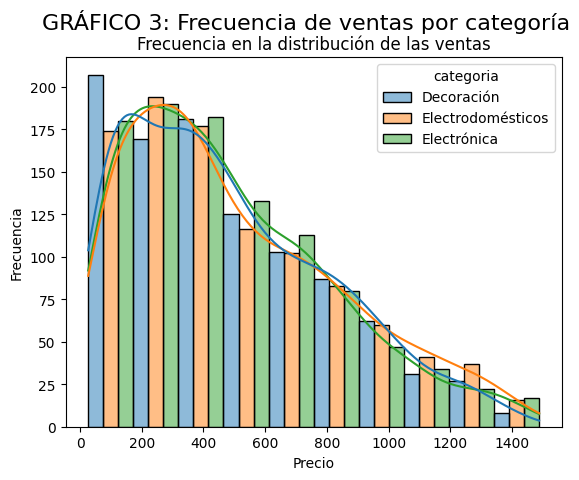

In [49]:
plt.suptitle('GRÁFICO 3: Frecuencia de ventas por categoría', fontsize=16)
sns.histplot(dfVentas, x='precio_final', bins=10, kde=True, hue='categoria', multiple='dodge')
plt.title('Frecuencia en la distribución de las ventas')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

plt.show()

In [50]:
describe_ventas = dfVentas[['precio', 'cantidad', 'precio_final']].describe().round(2)
describe_ventas

,precio,cantidad,precio_final
count,2998.00,2998.00,2998.00
mean,75.29,6.50,489.36
std,28.74,3.46,334.28
min,26.00,1.00,26.30
25%,50.03,3.00,220.92
50%,75.20,7.00,418.06
75%,100.07,9.00,709.92
max,124.97,12.00,1488.12


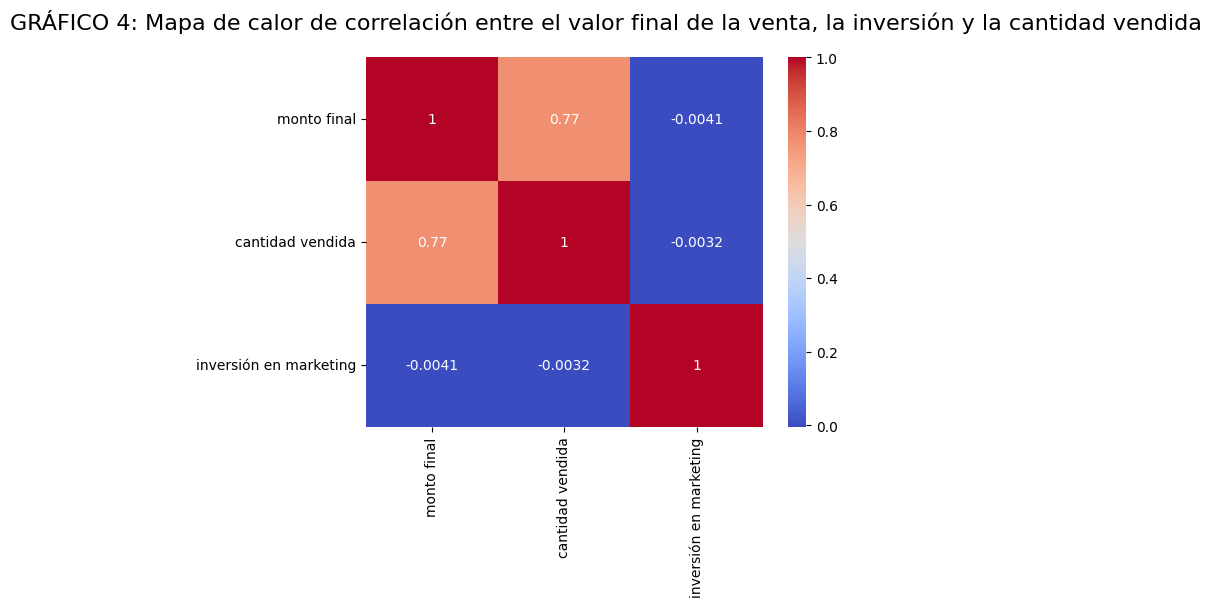

In [51]:
corr = mergeVentasMarketing[['precio_final', 'cantidad', 'inversión en marketing']].corr()
corr.rename(columns={'precio_final': 'monto final', 'cantidad': 'cantidad vendida'},
            index={'precio_final': 'monto final', 'cantidad': 'cantidad vendida'},
            inplace=True)
corr

plt.suptitle('GRÁFICO 4: Mapa de calor de correlación entre el valor final de la venta, la inversión y la cantidad vendida', fontsize=16)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()




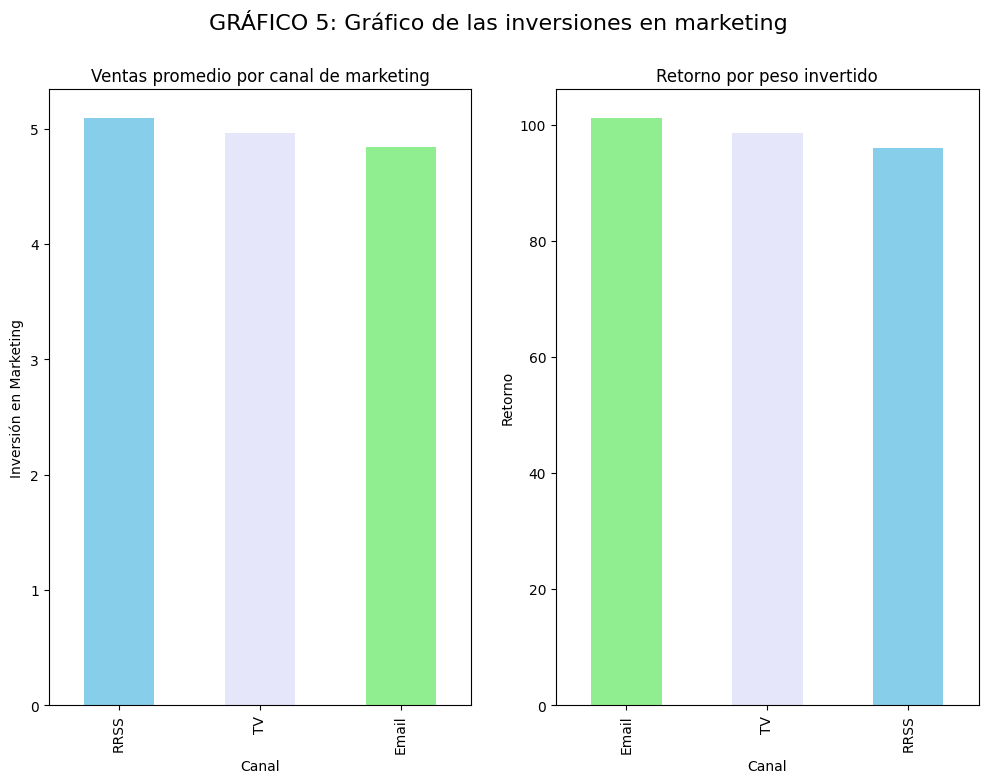

In [52]:
plt.figure(figsize=(12, 8))
plt.suptitle('GRÁFICO 5: Gráfico de las inversiones en marketing', fontsize=16)

# Ventas promedio por canal
inversionPromedioPorCanal = mergeVentasMarketing.groupby('canal')['inversión en marketing'].mean().round(2)
inversionPromedioPorCanal.sort_values(ascending=False, inplace=True)

plt.subplot(1, 2, 1)
inversionPromedioPorCanal.plot(kind='bar', color=['skyblue', '#E6E6FA', 'lightgreen'])
plt.title('Ventas promedio por canal de marketing')
plt.xlabel('Canal')
plt.ylabel('Inversión en Marketing')


# Calcular retorno por peso invertido
totalVentasPorCanal = mergeVentasMarketing.groupby('canal')['precio_final'].sum()
totalInversionPorCanal = mergeVentasMarketing.groupby('canal')['inversión en marketing'].sum()

totalVentasPorCanal = totalVentasPorCanal.round(2)
totalInversionPorCanal = totalInversionPorCanal.round(2)

retornoPorPesoInvertido = (totalVentasPorCanal / totalInversionPorCanal).round(2)
retornoPorPesoInvertido.sort_values(ascending=False, inplace=True)

plt.subplot(1, 2, 2)
retornoPorPesoInvertido.plot(kind='bar', color=['lightgreen', '#E6E6FA', 'skyblue'])
plt.title('Retorno por peso invertido')
plt.xlabel('Canal')
plt.ylabel('Retorno')

plt.show()


### Analísis:
El Informe Estadístico sobre el DataFrame Ventas revela un sesgo en los datos: El promedio es de unos 489 pesos, y la mediano ronda los 418 pesos, diferencia importante. Refuerza el sesgo los valores que refleja la moda: 345 y 1000 pesos.
La desviación estándar es de 334 pesos, una referencia alta de dispersión.

En base a lo representado en el Gráfico 1, la categoría más vendida es Electromésticos superando los 500 mil pesos en ventas. En base a lo expuesto en el Resumen el promedio en ventas por categoría es de 489 mil pesos, y la categoría con la menor cantidad de ventas es Decoración con 479 mil pesos.
La diferencia entre el máximo y el mínimo con el promedio ronda los 10 mil pesos. La categoría Electrónica, por su parte, genero un total de 482 mil pesos en ventas
A través de este mismo Gráfico 1 y el Resumen se observan valores máximos, mínimos y promedios de los distintos productos agrupados por categorías.

- Decoración:
  - max: Lámpara de mesa (82276,38 pesos)
  - min: Candelabro (11128,80 pesos)
  - prom: 47921,61 pesos
  - dv: 17056,19 pesos
- Electrodomésticos:
  - max: Microondas (72562,89 pesos)
  - min: Heladera (25736,80 pesos)
  - prom: 50529,96 pesos
  - dv: 11628,19 pesos
- Electrónica:
  - max: Auriculares (74175,58 pesos)
  - min: Tablet (25856,57 pesos)
  - prom: 48257,78 pesos
  - dv: 11680,26 pesos

  El producto con más ventas acumuladas fue la Lámpara de mesa con más de 82 mil pesos, de la categoría decoración (menos ventas generales) y el que menos acumulo el Candelabro de la misma catecogría.
  Los productos más vendidos de las otras categorías oscilan los 74 mil pesos y los menos vendidos los 25 mil.
  El promedio es de unos 50 mil pesos, los montos máximos superan notablente este valor, y la desviación estándar es alta, ronda los 12 mil pesos promedio de las tres categorías, dejando en evidencia el sesgo en los datos. Notable también en los montos máximos y mínimos.

  El Gráfico 2 refleja los outliers marcados tanto máximos como mínimos en cada categoría, y una tendencia a acumular valores en el rango de 40500 y 55000 pesos.
  En el Gráfico 3 se representan la frecuencia de las ventas por categorías. La mayor frecuencia de ventas se da en productos con montos de 350 pesos aproximadamente para ir descendiendo abruptamente en los montos más alto 1200/1400 pesos. Se destaca Decoración como la categoría con mayor frecuencia en productos que no superan los 150 pesos.

  Describe_Ventas nos brinda un panorama de tres columnas específicas: precio, cantidad y precio_final.
  El promedio en precios es de 75.29, el monto máximo es de 124.97 y el mínimo de 26 pesos. En promedio de cantidad vendida por producto es de 6.5, la mayor cantidad de productos vendidos fueron 12 y el mínimo 1. El promedio del monto final vendido ronda los 489 pesos y el monto máximo 1488 mientras que el mínimo es de 26.30 pesos.
  La desviación estándar es alta, en el caso de los precios por producto se nota una dispersión moderada/alta pero no con una marcada diferencia como en los otros dos casos.

  El Gráfico 4 muestra la correlación entre el monto final, la cantidad vendida y la inversión en marketing. La correlación es negativa y débil, excepto entre cantidad vendida y monto final de la venta, pero este dado es esperable ya que es lógico que a mayor cantidad vendida aumente el monto final.

  Por último el Gráfico 5 nos permite identificar a las RRSS como el canal de marketing con mayor promedio de inversión y en conjunto con el segundo gráfico de barras se evidencia que es el canal que menos retorno por peso invertido genero. A diferencia del canal Email, que es el que más retorno tuvo y el que menos inversión recibió.    

###--------------------------------------------------------------------------------

/tmp/ipython-input-147911521.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-147911521.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




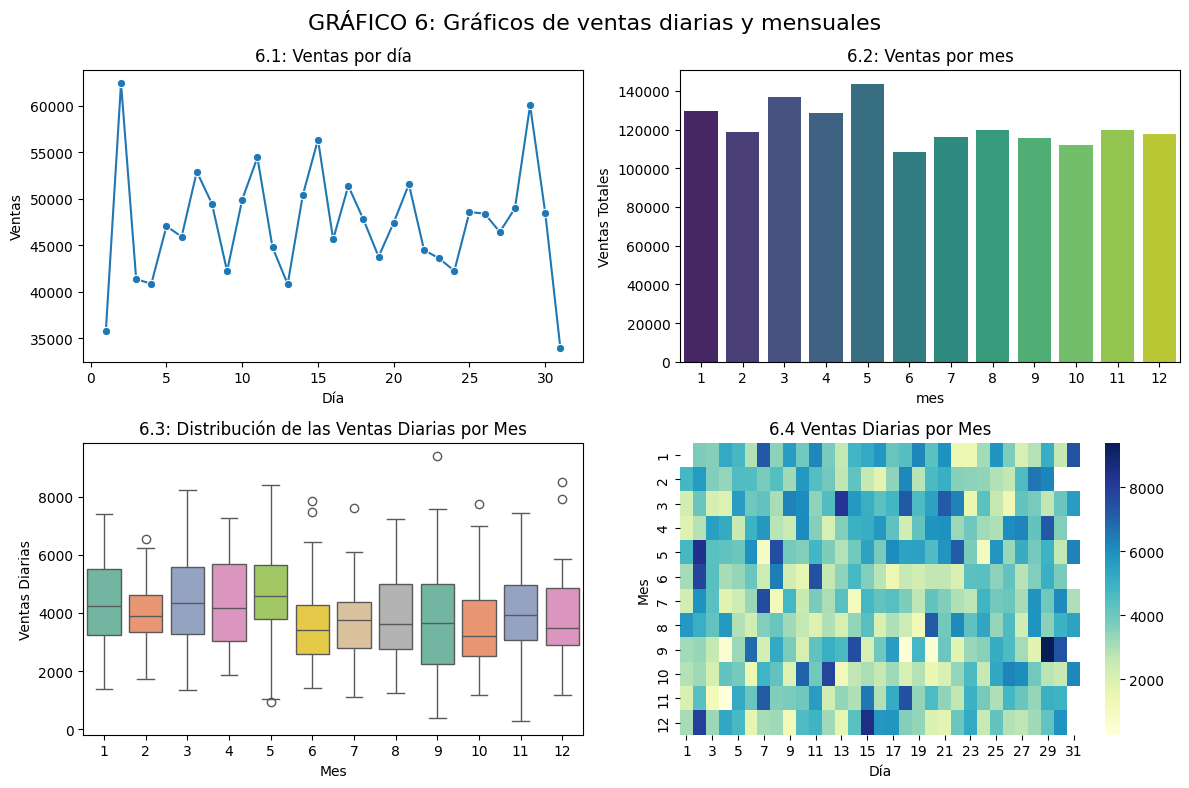

In [53]:
plt.figure(figsize=(12, 8))
plt.suptitle('GRÁFICO 6: Gráficos de ventas diarias y mensuales', fontsize=16)

dfVentas['dia'] = pd.to_datetime(dfVentas['fecha_venta']).dt.day

ventas_por_dia = dfVentas.groupby('dia')['precio_final'].sum().sort_values(ascending=False)
ventas_por_mes = dfVentas.groupby('mes')['precio_final'].sum().sort_values(ascending=False)
ventas_diarias_mensuales = dfVentas.groupby(['dia', 'mes'])['precio_final'].sum().sort_values(ascending=False).reset_index()



plt.subplot(2, 2, 1)
sns.lineplot(x=ventas_por_dia.index, y=ventas_por_dia.values, marker='o')
plt.title('6.1: Ventas por día')
plt.xlabel('Día')
plt.ylabel('Ventas')

plt.subplot(2, 2, 2)
sns.barplot(x=ventas_por_mes.index, y=ventas_por_mes.values, palette='viridis')
plt.title('6.2: Ventas por mes')
plt.xlabel
plt.ylabel('Ventas Totales')

plt.subplot(2, 2, 3) # O la posición que desees para este gráfico
sns.boxplot(x=ventas_diarias_mensuales['mes'],
            y=ventas_diarias_mensuales['precio_final'],
            palette='Set2')
plt.title('6.3: Distribución de las Ventas Diarias por Mes')
plt.xlabel('Mes')
plt.ylabel('Ventas Diarias')

plt.subplot(2, 2, 4)
ventas_pivot = ventas_diarias_mensuales.pivot(index='mes', columns='dia', values='precio_final')
sns.heatmap(ventas_pivot, cmap="YlGnBu")
plt.title('6.4 Ventas Diarias por Mes')
plt.xlabel('Día')
plt.ylabel('Mes')

plt.tight_layout()
plt.show()


In [54]:
ingresosClientesPorCiudad = dfClientes.groupby('ciudad')['ingresos'].sum().sort_values(ascending=False).reset_index()
ingresosClientesPorCiudad.sort_values(by='ingresos', ascending=False, inplace=True)

fig = px.bar(ingresosClientesPorCiudad,
             x='ciudad',
             y='ingresos',
             color='ingresos',
             labels={'x': 'Ciudad', 'y': 'Ingresos'},
             hover_name='ciudad',
             hover_data={'ciudad':False})

fig.update_layout(title='Gráfico 7: Ingresos de los Clientes por Ciudad',
                  xaxis_title='Ciudad',
                  yaxis_title='Ingresos',
                  plot_bgcolor='white')
fig.show()


In [55]:
dfClientes

,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65
...,...,...,...,...,...
562,563,Dione Forsyde,29,Posadas,26757.73
563,564,Fleming Gow,39,Santa Fe,43674.96
564,565,Jewelle Mabbett,33,Córdoba,30522.64
565,566,Lauri Munns,23,Resistencia,31259.14


In [56]:
clientesPorCiudad = dfClientes.groupby('ciudad')['id_cliente'].count().sort_values(ascending=False).reset_index()
clientesPorCiudad.rename(columns={'id_cliente': 'cantidad de personas'}, inplace=True)

promedioEdadPorCiudad = dfClientes.groupby('ciudad')['edad'].mean().round(2).sort_values(ascending=False).reset_index()
promedioEdadPorCiudad.rename(columns={'edad': 'promedio de edad'}, inplace=True)

df_merge = clientesPorCiudad.merge(promedioEdadPorCiudad, on='ciudad')

fig = px.scatter(df_merge,
                 x='cantidad de personas',
                 y='ciudad',
                 color='promedio de edad',
                 size='cantidad de personas',
                 hover_name='ciudad',
                 hover_data={'ciudad':False},
                 labels={'x': 'cantidad de personas', 'y': 'ciudades'})

fig.update_layout(title='Gráfico 8: Relación entre la cantidad de personas y el promedio de edad en cada ciudad',
                  plot_bgcolor='white')
fig.show()


In [57]:
ventasMensuales = dfVentas.groupby('mes')['precio_final'].sum()
ventasMensuales = ventasMensuales.sort_index()

fig = px.line(
    ventasMensuales,
    x=ventasMensuales.index,
    y=ventasMensuales.values,
    labels={'x': 'Mes', 'y': 'Ventas'},
    title='Ventas Mensuales',
    line_shape='spline', # suaviza las curvas
    render_mode='svg')

fig.update_layout(
    title='Gráfico 9 : Distribución de las Ventas Mensuales',
    xaxis_title='Mes',
    yaxis_title='Ventas',
    plot_bgcolor='white')

fig.show()

Dropdown(description='Ciudad:', options=('Corrientes', 'Córdoba', 'Posadas', 'Salta', 'Mar del Plata', 'Resist…

IntRangeSlider(value=(20, 81), continuous_update=False, description='Rango Edad:', max=81, min=20)

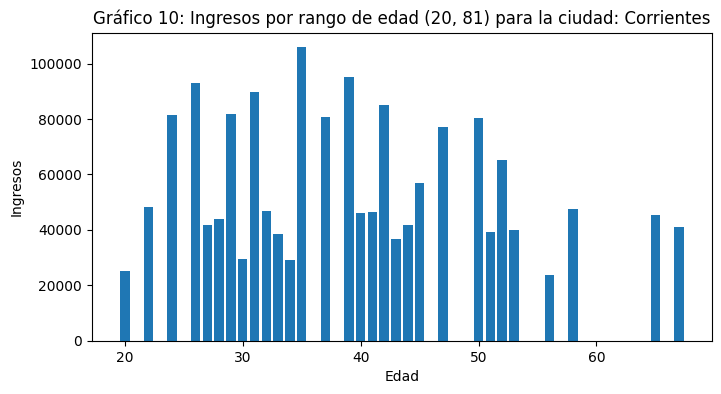

interactive(children=(Output(),), _dom_classes=('widget-interact',))

In [58]:
ingresos_por_edad_y_ciudad = dfClientes.groupby(['edad', 'ciudad'])['ingresos'].sum().reset_index()

ciudades = ingresos_por_edad_y_ciudad['ciudad'].unique()

selector_ciudad = widgets.Dropdown(
    options=ciudades,
    value=ciudades[0],
    description='Ciudad:',
    disabled=False,
)

selector_edad = widgets.IntRangeSlider(
    value=[ingresos_por_edad_y_ciudad['edad'].min(), ingresos_por_edad_y_ciudad['edad'].max()],
    min=ingresos_por_edad_y_ciudad['edad'].min(),
    max=ingresos_por_edad_y_ciudad['edad'].max(),
    step=1,
    description='Rango Edad:',
    continuous_update=False
)

display(selector_ciudad, selector_edad)

def filtrar_datos(ciudad, rango_edad):
    df_filtrado = ingresos_por_edad_y_ciudad.copy()
    df_filtrado = df_filtrado[df_filtrado['ciudad'] == ciudad]
    df_filtrado = df_filtrado[(df_filtrado['edad'] >= rango_edad[0]) &
                              (df_filtrado['edad'] <= rango_edad[1])]
    return df_filtrado

def actualizar_grafico():
    ciudad = selector_ciudad.value
    rango_edad = selector_edad.value
    df = filtrar_datos(ciudad, rango_edad)

    plt.figure(figsize=(8,4))
    plt.bar(df['edad'], df['ingresos'])
    plt.xlabel("Edad")
    plt.ylabel("Ingresos")
    plt.title(f'Gráfico 10: Ingresos por rango de edad {rango_edad} para la ciudad: {ciudad}')
    plt.show()

actualizar_grafico()

# ENLACE CORRECTO CON WIDGETS
selector_ciudad.observe(lambda change: actualizar_grafico(), names='value')
selector_edad.observe(lambda change: actualizar_grafico(), names='value')

# Crear widget interactivo
interaccion = widgets.interactive(actualizar_grafico,
                                  ciudad=selector_ciudad.value,
                                  rango_edad=selector_edad.value)

# Mostrar widget y gráfico interactivo
display(interaccion)

In [59]:
ventas_inversion_mensuales_por_categoria = mergeVentasMarketing.groupby(['categoria', 'mes'])[['precio_final', 'inversión en marketing']].sum().reset_index()

fig = px.line(ventas_inversion_mensuales_por_categoria.sort_values(by=['precio_final']),
              x='precio_final',
              y='inversión en marketing',
              color='categoria',
              title='Gráfico 11 : Relación entre el marketing y las ventas por categoría')

fig.show()

In [60]:
ventas_inversion_mensuales_por_categoria['cuatrimestre'] = ((ventas_inversion_mensuales_por_categoria['mes']-1) // 4) + 1
ventas_inversion_mensuales_por_categoria.sort_values(by=['cuatrimestre', 'precio_final'],
                                                     inplace=True,
                                                     ascending=[True, False])

fig = px.line(ventas_inversion_mensuales_por_categoria,
              x='precio_final',
              y='inversión en marketing',
              color='cuatrimestre',
              title='Gráfico 12 : Relación entre inversióin en publicidad y ventas analizadas por cuatrimestres')

fig.show()

### Análisis:

El Gráfico 6: representa el comportamiento de las ventas día y día, y analizadas de manera mensual. El Gráfico 6.1 permite observas picos de ventas en tres momentos claves del mes: durante los primeros 3 días, a mediado de mes y sobre los último días existe una tendencia a la alta pero acompañado de una fuerte caída. En el Gráfico 6.2 agrupa la mayor cantidad de ventas durante los primeros 5 meses. En el Gráfico 6.3 se observa que la distribución de ventas mensualmente es relativamente simétrica, se presentan outliers y bigotes largos que pueden deberse a la naturalidad en la variación de precios. Pudiendo suponer que las distribuciones presentan colas densas generadas por la variabilidad de los montos de las ventas. Por último en el Gráfico 6.4 se ve una tendencia a ventas diarias que rondan los 4000/6000 pesos, con una tendencia a recibir compras que superen los 8000 pesos durante los primeros 15 días.

En el Gráfico 7 se presenta el ingreso de los clientes por ciudad. Destancando Mar del Plata, Rosario, Posadas, resistencia como las ciudades con mayores ingresos. En tanto, San Miguel de Tucuman y Buenos Aires como las ciudades con menos ingresos.  

El promedio de edad de los clientes tiende a no superar los 38 años y las ciudades con menos clientes tienen un promedio de 36 años de edad, según se observa en el Gráfico 8.

Se visualiza, a través del Gráfico 9, un notable creciemiento en ventras en los primeros meses hasta Mayo en dónde se alcanza el máximo en ventas. Luego hay un fuerte descenso que se mantiene estable en unos 115 mil pesos en ventas mensuales hasta fin de año.

El Gráfico 10 permite analizar en cada ciudad el ingreso por edad de los cliente. A simple vista el rango etario con mayores ingresos se centra entre los 30/40 años de edad.

La inversión en publicidad por categoría, expuesta en el Gráfico 11 refleja que cuando no se realizan inversiones en publicidad para la categoría decoración se producen bajas en las ventas. En electrónica los gastos en publicidad cuando son paulatinos y constantes permiten mantener un nivel estable de ventas. Y para la categoría electrodomésticos, a medida que aumenta el costo en publicidad se refleja un incremento en ventas.
Por su parte, el Gráfico 12 deja en claro que durante el primer cuatrimestre, a medida, que aumenta la publidad se genera un aumento en ventas. Y el tercer cuatrimestre siempre permanece debajop en ventas a pesar de las inversiones en la publicidad.



#Análisis final:

Los datos de ventas muestran mucha variabilidad y presencia de valores extremos, lo que genera grandes diferencia entre mínimos, máximos y promedios. También aparece un sesgo claro.

La categoría con más ventas es Electródmesticos y Decoración la más débil. Hay productos dentro de cada categoría que se destacan mucho frente a otros, lo que también explica parte de la dispersión.

El mejor desempeño en ventas es entre Enero y Mayo, pero se destacan picos también a mediado y a fin de mes. Depués los valores bajan y se mantienen estables.

Los clientes tiene un promedio de edad de 35 años y ciudades como Mar Del Plata, Rosario y Posadas generan los mayores ingresos.

En marketing no se garantiza que a mayor inversión se obtengan mejores resultados. RRSS es el canal dónde más se gasta pero que menos retorno ofrece, mientras que con Email ocurre lo contrario.

####En resumen, aqunque los datos son muy dispersos, los análisis permiten identificar patrones claros en categorías, clientes, temporalidad y marketing, ayudando a comprender el comportamiento general de las ventas.